In [13]:
import pandas as pd
run1_df = pd.read_csv("run1.csv")
run1_df.head()

,seq,ground_tru,predicted
0,1,wink,unknown
1,2,embarrassed,unknown
2,3,sad,unknown
3,4,smile,unknown
4,5,surprised,unknown


In [14]:
import pandas as pd
run2_df = pd.read_csv("run2.csv")
run2_df.head()

,seq,ground_tru,predicted
0,1,surprised,unknown
1,2,embassed,unknown
2,3,wink,unknown
3,4,sad,unknown
4,5,smile,unknown


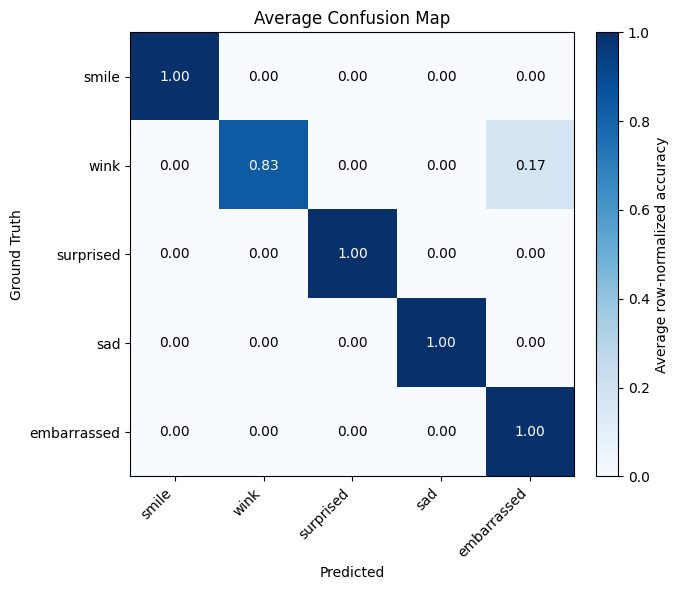

predicted,smile,wink,surprised,sad,embarrassed
ground_truth,,,,,
smile,1.0,0.000000,0.0,0.0,0.000000
wink,0.0,0.833333,0.0,0.0,0.166667
surprised,0.0,0.000000,1.0,0.0,0.000000
sad,0.0,0.000000,0.0,1.0,0.000000
embarrassed,0.0,0.000000,0.0,0.0,1.000000


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

labels = ["smile", "wink", "surprised", "sad", "embarrassed"]
label_aliases = {"embassed": "embarrassed"}


def normalize_results(df):
    df = df.copy()
    gt_col = "ground_truth" if "ground_truth" in df.columns else "ground_tru"
    pred_col = "predicted"
    df = df.rename(columns={gt_col: "ground_truth", pred_col: "predicted"})
    df["ground_truth"] = df["ground_truth"].replace(label_aliases)
    df["predicted"] = df["predicted"].replace(label_aliases)
    df = df[df["predicted"].ne("unknown")]
    df = df[df["ground_truth"].isin(labels) & df["predicted"].isin(labels)]
    return df


def confusion_map(df):
    return pd.crosstab(
        df["ground_truth"],
        df["predicted"],
        normalize="index",
    ).reindex(index=labels, columns=labels, fill_value=0)

run1_clean = normalize_results(run1_df)
run2_clean = normalize_results(run2_df)
cm1 = confusion_map(run1_clean)
cm2 = confusion_map(run2_clean)
avg_cm = (cm1 + cm2) / 2

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(avg_cm.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Ground Truth")
ax.set_title("Average Confusion Map")

for i in range(len(labels)):
    for j in range(len(labels)):
        value = avg_cm.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value >= 0.5 else "black",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Average row-normalized accuracy")
fig.tight_layout()
fig.savefig("avg_confusion_map.png", dpi=200, bbox_inches="tight")
plt.show()
avg_cm

In [16]:
print('run1 columns:', list(run1_df.columns))
print('run2 columns:', list(run2_df.columns))
print(run1_df.head())
print(run2_df.head())

run1 columns: ['seq', 'ground_tru', 'predicted']
run2 columns: ['seq', 'ground_tru', 'predicted']
   seq   ground_tru predicted
0    1         wink   unknown
1    2  embarrassed   unknown
2    3          sad   unknown
3    4        smile   unknown
4    5    surprised   unknown
   seq ground_tru predicted
0    1  surprised   unknown
1    2   embassed   unknown
2    3       wink   unknown
3    4        sad   unknown
4    5      smile   unknown


In [17]:
# output the average overall accuracy
overall_acc1 = (run1_clean["ground_truth"] == run1_clean["predicted"]).mean()
overall_acc2 = (run2_clean["ground_truth"] == run2_clean["predicted"]).mean()
avg_overall_acc = (overall_acc1 + overall_acc2) / 2
print(f"Average Overall Accuracy: {avg_overall_acc:.2%}")

Average Overall Accuracy: 96.67%
